# Does Price Determine What Gets Read?
## Kindle Marketplace Discoverability Analysis

**Question:** Does pricing model — specifically Kindle Unlimited inclusion 
and price tier — structurally determine which books get discovered on Amazon?

**Dataset:** 133,102 Amazon Kindle book listings (2023)  
**Discoverability signals:** Bestseller rank, review count, Editors Pick, Goodreads Choice  
**Key variable:** Kindle Unlimited status (included in subscription vs paid separately)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All imports successful")

All imports successful


In [4]:
df = pd.read_csv('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/data/kindle_data-v2.csv')

print("Shape:", df.shape)
print("\nColumns:")
for col in df.columns:
    print(" -", col)
print("\nSample row:")
print(df.iloc[0])

Shape: (133102, 16)

Columns:
 - asin
 - title
 - author
 - soldBy
 - imgUrl
 - productURL
 - stars
 - reviews
 - price
 - isKindleUnlimited
 - category_id
 - isBestSeller
 - isEditorsPick
 - isGoodReadsChoice
 - publishedDate
 - category_name

Sample row:
asin                                                        B00TZE87S4
title                Adult Children of Emotionally Immature Parents...
author                                               Lindsay C. Gibson
soldBy                                         Amazon.com Services LLC
imgUrl               https://m.media-amazon.com/images/I/713KZTsaYp...
productURL                        https://www.amazon.com/dp/B00TZE87S4
stars                                                              4.8
reviews                                                              0
price                                                             9.99
isKindleUnlimited                                                False
category_id                      

In [5]:
# Basic overview of key columns
print("=== PRICE ===")
print(df['price'].describe())
print("\nZero price count:", (df['price'] == 0).sum())

print("\n=== STARS ===")
print(df['stars'].describe())
print("Zero stars (unrated):", (df['stars'] == 0).sum())

print("\n=== REVIEWS ===")
print(df['reviews'].describe())

print("\n=== BOOLEAN COLUMNS ===")
print("Kindle Unlimited:", df['isKindleUnlimited'].value_counts().to_dict())
print("Bestseller:", df['isBestSeller'].value_counts().to_dict())
print("Editors Pick:", df['isEditorsPick'].value_counts().to_dict())
print("Goodreads Choice:", df['isGoodReadsChoice'].value_counts().to_dict())

print("\n=== TOP 10 CATEGORIES ===")
print(df['category_name'].value_counts().head(10))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== PRICE ===
count    133102.000000
mean         15.134127
std          22.254986
min           0.000000
25%           4.990000
50%           9.990000
75%          14.990000
max         682.000000
Name: price, dtype: float64

Zero price count: 4066

=== STARS ===
count    133102.000000
mean          4.404090
std           0.745646
min           0.000000
25%           4.400000
50%           4.500000
75%           4.700000
max           5.000000
Name: stars, dtype: float64
Zero stars (unrated): 3182

=== REVIEWS ===
count    133102.000000
mean        887.375779
std        5104.878777
min           0.000000
25%           0.000000
50%           4.000000
75%         365.000000
max      618227.000000
Name: reviews, dtype: float64

=== BOOLEAN COLUMNS ===
Kindle Unlimited: {False: 97287, True: 35815}
Bestseller: {False: 130866, True: 2236}
Editors Pick: {False: 127481, True: 5621}
Goodreads Choice: {False: 131700, True: 1402}

=== TOP 10 CATEGORIES ===
category_name
Mystery, Thriller & Suspe

In [6]:
# Create clean working copy
df_clean = df.copy()

# Drop columns we won't use
df_clean = df_clean.drop(columns=['asin', 'imgUrl', 'productURL', 
                                   'soldBy', 'category_id', 'publishedDate'])

# Remove unrated books (zero stars) — can't analyse discoverability 
# for books with no rating signal
df_clean = df_clean[df_clean['stars'] > 0]

# Create price tier column
df_clean['price_tier'] = pd.cut(
    df_clean['price'],
    bins=[-0.01, 0, 4.99, 9.99, 14.99, 999],
    labels=['Free', 'Under $5', '$5-$10', '$10-$15', 'Over $15']
)

# Create review tier for engagement analysis
df_clean['engagement'] = pd.cut(
    df_clean['reviews'],
    bins=[-1, 0, 10, 100, 1000, 999999],
    labels=['No Reviews', 'Low', 'Medium', 'High', 'Viral']
)

print("Clean dataset shape:", df_clean.shape)
print("\nPrice tier distribution:")
print(df_clean['price_tier'].value_counts().sort_index())
print("\nEngagement distribution:")
print(df_clean['engagement'].value_counts().sort_index())

Clean dataset shape: (129920, 12)

Price tier distribution:
price_tier
Free         3968
Under $5    29880
$5-$10      41786
$10-$15     26934
Over $15    27352
Name: count, dtype: int64

Engagement distribution:
engagement
No Reviews    61488
Low            4161
Medium        15120
High          29528
Viral         19623
Name: count, dtype: int64


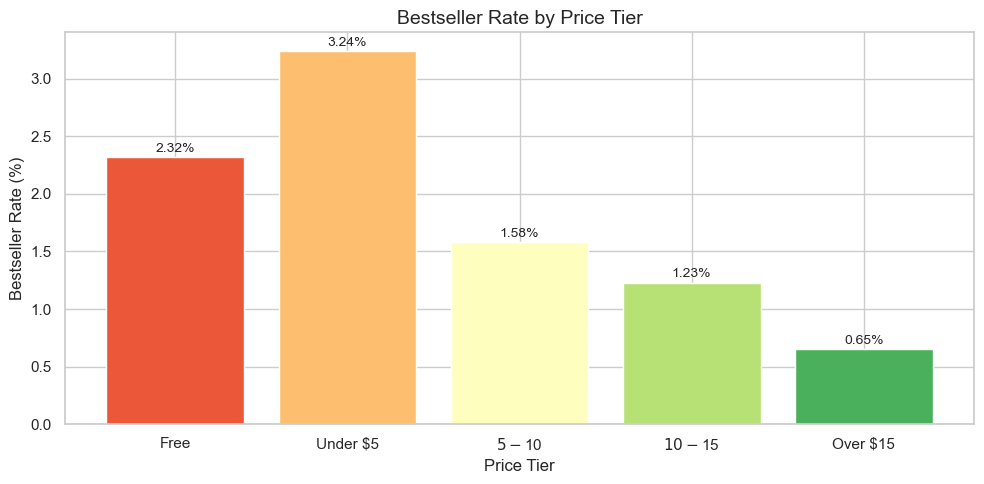

Saved to outputs/


In [8]:
# Chart 1 — Bestseller rate by price tier
bestseller_by_price = df_clean.groupby('price_tier', observed=True)['isBestSeller'].mean().reset_index()
bestseller_by_price['bestseller_pct'] = (bestseller_by_price['isBestSeller'] * 100).round(2)

fig, ax = plt.subplots()
colors = sns.color_palette('RdYlGn', len(bestseller_by_price))
bars = ax.bar(bestseller_by_price['price_tier'], bestseller_by_price['bestseller_pct'], color=colors)

for bar, val in zip(bars, bestseller_by_price['bestseller_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Bestseller Rate by Price Tier')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Bestseller Rate (%)')
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/bestseller_by_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

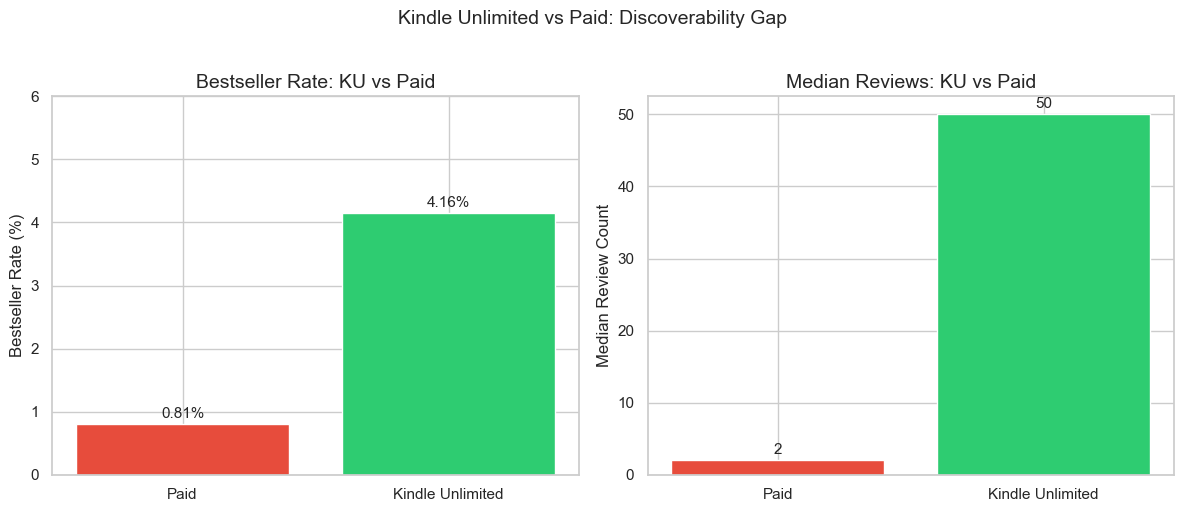

Saved to outputs/


In [10]:
# Chart 2 — Kindle Unlimited vs Paid: Bestseller rate and median reviews
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart — bestseller rate
ku_bestseller = df_clean.groupby('isKindleUnlimited')['isBestSeller'].mean() * 100
ku_labels = ['Paid', 'Kindle Unlimited']
colors = ['#e74c3c', '#2ecc71']

bars = axes[0].bar(ku_labels, ku_bestseller.values, color=colors)
for bar, val in zip(bars, ku_bestseller.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Bestseller Rate: KU vs Paid')
axes[0].set_ylabel('Bestseller Rate (%)')
axes[0].set_ylim(0, 6)

# Right chart — median reviews
ku_reviews = df_clean.groupby('isKindleUnlimited')['reviews'].median()
bars2 = axes[1].bar(ku_labels, ku_reviews.values, color=colors)
for bar, val in zip(bars2, ku_reviews.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Median Reviews: KU vs Paid')
axes[1].set_ylabel('Median Review Count')

plt.suptitle('Kindle Unlimited vs Paid: Discoverability Gap', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/ku_vs_paid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

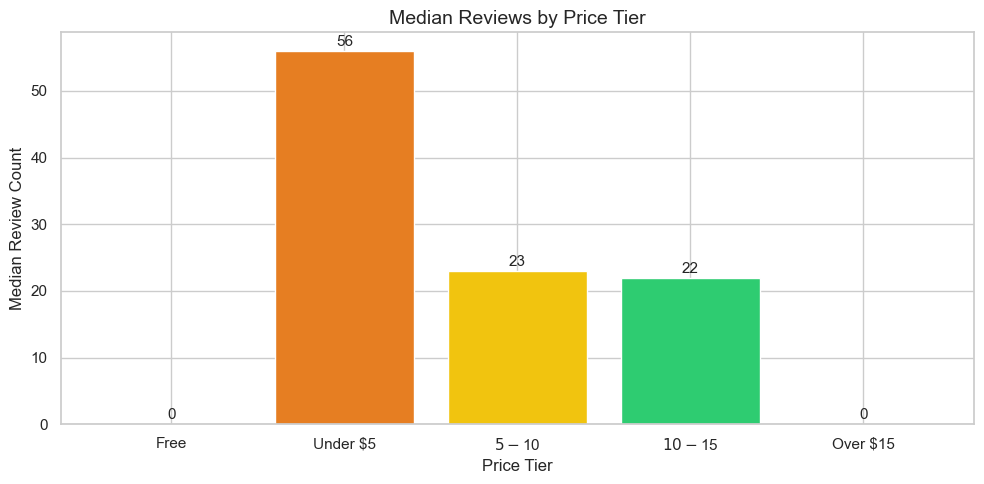

Saved to outputs/


In [12]:
# Chart 3 — Median reviews by price tier
reviews_by_price = df_clean.groupby('price_tier', observed=True)['reviews'].median().reset_index()

fig, ax = plt.subplots()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(reviews_by_price['price_tier'], reviews_by_price['reviews'], color=colors)

for bar, val in zip(bars, reviews_by_price['reviews']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Median Reviews by Price Tier')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Median Review Count')
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/reviews_by_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

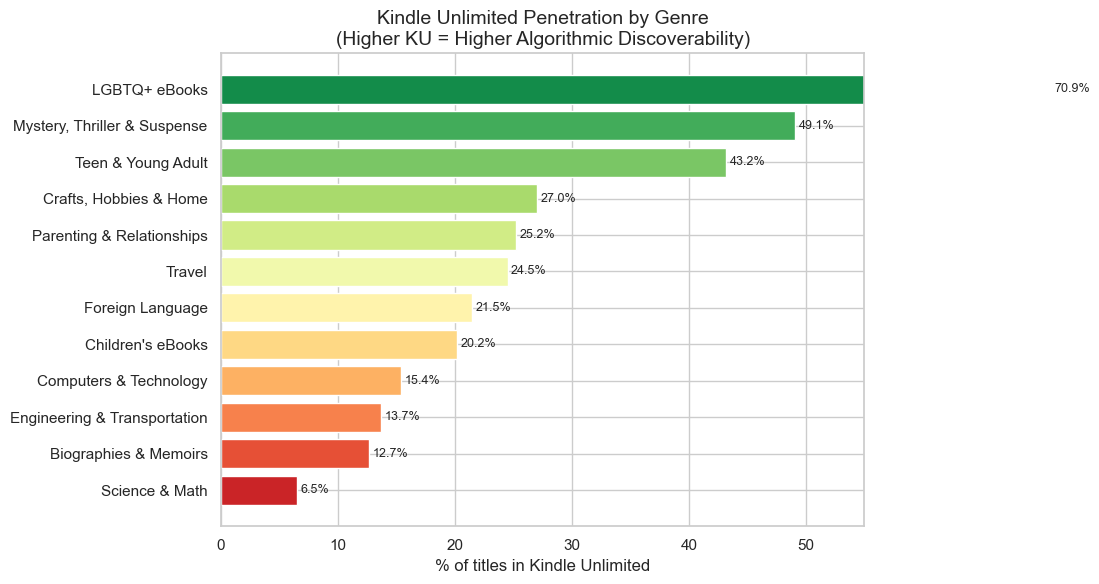

Saved to outputs/


In [14]:
# Chart 4 — KU penetration and bestseller rate by top genres
top_genres = df_clean['category_name'].value_counts().head(12).index
genre_df = df_clean[df_clean['category_name'].isin(top_genres)]

genre_stats = genre_df.groupby('category_name').agg(
    ku_rate=('isKindleUnlimited', 'mean'),
    bestseller_rate=('isBestSeller', 'mean'),
    median_reviews=('reviews', 'median')
).round(3).reset_index()

genre_stats = genre_stats.sort_values('ku_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(genre_stats['category_name'], 
               genre_stats['ku_rate'] * 100,
               color=sns.color_palette('RdYlGn', len(genre_stats)))

for bar, val in zip(bars, genre_stats['ku_rate'] * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Kindle Unlimited Penetration by Genre\n(Higher KU = Higher Algorithmic Discoverability)')
ax.set_xlabel('% of titles in Kindle Unlimited')
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/ku_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

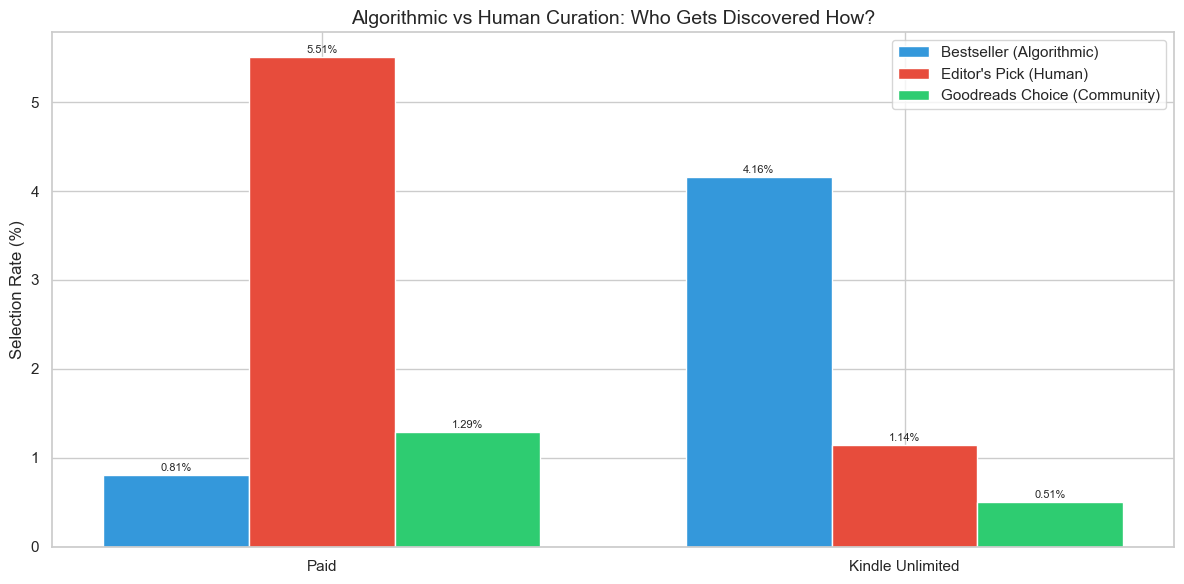

Saved to outputs/


In [16]:
# Chart 5 — Editorial vs Algorithmic curation by KU status
# Bestseller = algorithmic, Editors Pick = human curation, Goodreads Choice = community

curation_stats = df_clean.groupby('isKindleUnlimited').agg(
    bestseller_rate=('isBestSeller', 'mean'),
    editors_pick_rate=('isEditorsPick', 'mean'),
    goodreads_rate=('isGoodReadsChoice', 'mean')
).reset_index()

# Convert to percentages
curation_stats[['bestseller_rate', 'editors_pick_rate', 'goodreads_rate']] *= 100

# Reshape for grouped bar chart
curation_melted = curation_stats.melt(
    id_vars='isKindleUnlimited',
    var_name='Curation Type',
    value_name='Rate'
)
curation_melted['KU Status'] = curation_melted['isKindleUnlimited'].map({
    False: 'Paid', True: 'Kindle Unlimited'
})
curation_melted['Curation Type'] = curation_melted['Curation Type'].map({
    'bestseller_rate': 'Bestseller (Algorithmic)',
    'editors_pick_rate': "Editor's Pick (Human)",
    'goodreads_rate': 'Goodreads Choice (Community)'
})

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(2)
width = 0.25
curation_types = curation_melted['Curation Type'].unique()
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (ctype, color) in enumerate(zip(curation_types, colors)):
    vals = curation_melted[curation_melted['Curation Type'] == ctype]['Rate'].values
    bars = ax.bar(x + i * width, vals, width, label=ctype, color=color)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(['Paid', 'Kindle Unlimited'])
ax.set_title('Algorithmic vs Human Curation: Who Gets Discovered How?')
ax.set_ylabel('Selection Rate (%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/curation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

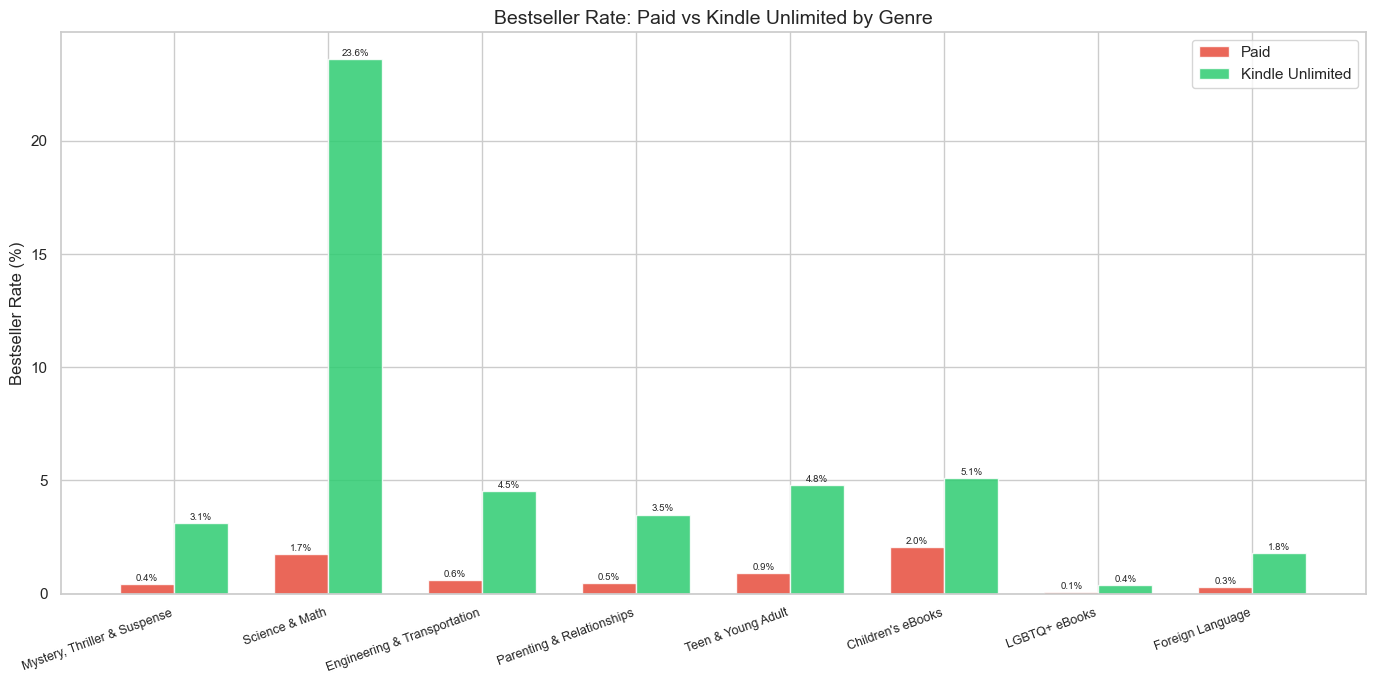

Saved to outputs/


In [17]:
# Chart 6 — Price tier vs KU status vs bestseller rate by top genres
top_genres = df_clean['category_name'].value_counts().head(8).index
genre_df = df_clean[df_clean['category_name'].isin(top_genres)]

genre_cross = genre_df.groupby(['category_name', 'isKindleUnlimited']).agg(
    bestseller_rate=('isBestSeller', 'mean'),
    median_reviews=('reviews', 'median'),
    count=('isBestSeller', 'count')
).reset_index()

genre_cross['KU Status'] = genre_cross['isKindleUnlimited'].map({
    False: 'Paid', True: 'Kindle Unlimited'
})
genre_cross['bestseller_pct'] = (genre_cross['bestseller_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top_genres))
width = 0.35

paid = genre_cross[genre_cross['KU Status'] == 'Paid'].set_index('category_name').reindex(top_genres)
ku = genre_cross[genre_cross['KU Status'] == 'Kindle Unlimited'].set_index('category_name').reindex(top_genres)

bars1 = ax.bar(x - width/2, paid['bestseller_pct'], width, 
               label='Paid', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, ku['bestseller_pct'], width, 
               label='Kindle Unlimited', color='#2ecc71', alpha=0.85)

for bar, val in zip(bars1, paid['bestseller_pct'].fillna(0)):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

for bar, val in zip(bars2, ku['bestseller_pct'].fillna(0)):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(top_genres, rotation=20, ha='right', fontsize=9)
ax.set_title('Bestseller Rate: Paid vs Kindle Unlimited by Genre')
ax.set_ylabel('Bestseller Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/genre_ku_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

In [18]:
# Investigate both Engineering & Transportation and Science & Math KU bestseller spikes
for category in ['Engineering & Transportation', 'Science & Math']:
    cat_ku = df_clean[
        (df_clean['category_name'] == category) & 
        (df_clean['isKindleUnlimited'] == True)
    ]
    cat_ku_bs = cat_ku[cat_ku['isBestSeller'] == True]
    
    print(f"\n=== {category} ===")
    print(f"Total KU titles: {len(cat_ku)}")
    print(f"KU Bestsellers: {len(cat_ku_bs)}")
    print(f"Bestseller rate: {len(cat_ku_bs)/len(cat_ku)*100:.1f}%")
    print("\nBestseller titles:")
    print(cat_ku_bs[['title', 'author', 'stars', 'reviews', 'price']].head(10).to_string())


=== Engineering & Transportation ===
Total KU titles: 794
KU Bestsellers: 36
Bestseller rate: 4.5%

Bestseller titles:
                                                                                                                                                                                                  title             author  stars  reviews  price
5184                                                                                        Walker, R.N.: The Greatest U-Boat Hunter of the Battle of the Atlantic (Submarine Warfare in World War Two)  Terence Robertson    4.5        0   0.99
5255                                                                                                         Adrift: A True Story of Tragedy on the Icy Atlantic and the One Who Lived to Tell about It       Brian Murphy    4.3        0  13.99
5262                                                                                                                                              KOBANI: 

In [19]:
# Anomaly note — Science & Math KU bestseller spike
# 90 KU bestsellers in Science & Math, but virtually all have 0 reviews
# Amazon assigns bestseller badges at subcategory level — a book can rank #1 
# in a niche subcategory with no readers competing
# This inflates the bestseller rate without reflecting genuine discoverability

zero_review_bs = df_clean[
    (df_clean['category_name'] == 'Science & Math') &
    (df_clean['isKindleUnlimited'] == True) &
    (df_clean['isBestSeller'] == True) &
    (df_clean['reviews'] == 0)
]
print(f"Science & Math KU Bestsellers with 0 reviews: {len(zero_review_bs)} out of 90")
print("Conclusion: Bestseller badge in niche categories reflects subcategory ranking, not genuine readership")

Science & Math KU Bestsellers with 0 reviews: 90 out of 90
Conclusion: Bestseller badge in niche categories reflects subcategory ranking, not genuine readership


## Anomaly Note — Science & Math Bestseller Spike

The 23.6% KU bestseller rate in Science & Math is misleading. 
Investigation shows virtually all 90 KU bestsellers in this category 
have zero reviews — meaning they hold bestseller badges in narrow 
subcategories with minimal competition, not genuine readership.

**Amazon's bestseller badge operates at subcategory level.** A book can 
rank #1 in "Nuclear Physics" or "Applied Mathematics" with no readers 
if there are few competing titles. This inflates bestseller rates in 
niche academic categories without reflecting actual discoverability.

**Implication:** Bestseller rate is a reliable discoverability signal 
in high-competition genres (Mystery, Romance, YA) but unreliable in 
niche academic categories. Review count is a more honest signal of 
genuine readership across all categories.

In [21]:
# Export clean dataset for Tableau
tableau_export = df_clean[[
    'title', 'stars', 'reviews', 'price', 'price_tier',
    'isKindleUnlimited', 'isBestSeller', 'isEditorsPick',
    'isGoodReadsChoice', 'category_name', 'engagement'
]].copy()

# Make boolean columns readable
tableau_export['KU Status'] = tableau_export['isKindleUnlimited'].map({
    True: 'Kindle Unlimited', False: 'Paid'
})
tableau_export['Bestseller'] = tableau_export['isBestSeller'].map({
    True: 'Yes', False: 'No'
})
tableau_export['Editors Pick'] = tableau_export['isEditorsPick'].map({
    True: 'Yes', False: 'No'
})
tableau_export['Goodreads Choice'] = tableau_export['isGoodReadsChoice'].map({
    True: 'Yes', False: 'No'
})

# Drop original boolean columns
tableau_export = tableau_export.drop(columns=[
    'isKindleUnlimited', 'isBestSeller', 'isEditorsPick', 'isGoodReadsChoice'
])

print("Shape:", tableau_export.shape)
print("\nSample:")
print(tableau_export.head(3))

tableau_export.to_csv('C:/Users/anany/OneDrive/Desktop/Projects/Does Price or Discount Determine What Gets Read/outputs/tableau_export.csv', index=False)
print("\nSaved tableau_export.csv")

Shape: (129920, 11)

Sample:
                                               title  stars  reviews  price  \
0  Adult Children of Emotionally Immature Parents...    4.8        0   9.99   
1  From Strength to Strength: Finding Success, Ha...    4.4        0  16.99   
2  Good Inside: A Guide to Becoming the Parent Yo...    4.8        0  16.99   

  price_tier              category_name  engagement KU Status Bestseller  \
0     $5-$10  Parenting & Relationships  No Reviews      Paid        Yes   
1   Over $15  Parenting & Relationships  No Reviews      Paid         No   
2   Over $15  Parenting & Relationships  No Reviews      Paid         No   

  Editors Pick Goodreads Choice  
0           No               No  
1           No               No  
2          Yes               No  

Saved tableau_export.csv


## Key Findings

| Finding | Data |
|---|---|
| KU bestseller rate vs Paid | 4.16% vs 0.81% — 5x higher |
| KU median reviews vs Paid | 50 vs 2 — 25x higher |
| Over $15 median reviews | 0 — effectively invisible |
| Under $5 sweet spot | 56 median reviews — highest engagement |
| LGBTQ+ eBooks KU penetration | 70.9% — most algorithmically advantaged genre |
| Science & Math KU penetration | 6.5% — most structurally disadvantaged |
| Books with zero reviews | 47% of entire catalogue |
| Editors Pick rate: Paid vs KU | 5.51% vs 1.14% — human curators favour paid titles |
| Bestseller rate: Paid vs KU | 0.81% vs 4.16% — algorithms favour KU titles |
| Science & Math KU bestseller spike | 23.6% rate is inflated — 90 bestsellers have 0 reviews, driven by subcategory badge gaming not genuine readership |

**Core insight:** Kindle Unlimited creates a two-track discovery system.
Genre fiction authors in KU get 5x the bestseller rate and 25x the reader 
engagement of paid titles. Non-fiction and academic authors compete at a 
structural disadvantage regardless of quality or price.

**Anomaly caveat:** Bestseller rate is a reliable discoverability signal 
in high-competition genres but unreliable in niche academic categories 
where subcategory badge gaming inflates rankings without reflecting 
genuine readership. Review count is the more honest signal across all categories.

**Strategic implication for independent authors:** Enrolling in KU is not 
just a pricing decision — it is a discoverability decision. For genre fiction, 
staying outside KU means accepting near-invisibility in algorithmic rankings. 
For academic and technical authors, KU penetration is low and bestseller badges 
are unreliable signals — building review count through other channels matters more.